In [28]:
#getting python plotting functions, problems when I copy python folder into env modules folder
import sys
sys.path.insert(0, "/Users/ayman/Documents/GitHub/riesling/python")

import riesling as rlp

import sys
from pathlib import Path
import os

riesling_bin = Path.home() / "Documents" / "github" / "riesling" / "build" / "cxx" / "riesling"
os.environ["PATH"] += os.pathsep + str(riesling_bin)
!riesling

  riesling COMMAND {OPTIONS}

    RIESLING

  OPTIONS:

      GLOBAL OPTIONS
        -h, --help                        Show this help message
        -v[V], --verbosity=[V]            Log level 0-3
        --debug=[F]                       Write debug images to file
        --nthreads=[N]                    Limit number of threads
        --deflate=[D]                     Set deflate level (0=none)
      RECON
        recon-lsq                         Least-squares (iterative) recon
        recon-lsq2                        2D Least-squares (iterative) recon
        recon-rlsq                        Regularized least-squares recon
        recon-rlsq2                       2D Regularized least-squares recon
        recon-rss                         NUFFT + Root-Sum-Squares
        recon-rss2                        2D NUFFT + Root-Sum-Squares
        recon-rrss                        Regularized NUFFT + Root-Sum-Squares
      DATA
        h5                                Probe an H5 fil

In [29]:
import os
import requests
zenodo_files=['rawdata_brain_radial_96proj_12ch.h5', 'rawdata_spiral_ETH.h5']
data_dir = 'rrsg'
if not os.path.isdir(data_dir):
    os.mkdir(data_dir)

for zf in zenodo_files:
    if not os.path.isfile(f'{data_dir}/{zf}'):
        print(f'Downloading {zf}')
        res = requests.get(f'https://zenodo.org/record/3975887/files/{zf}')
        with open(f'{data_dir}/{zf}', 'wb') as h5f:
            h5f.write(res.content)
    else:
        print(f'Already downloaded {zf}')

In [30]:
import h5py
import numpy as np
matrix_sizes = [[256, 256], [220, 220]]
voxel_sizes = [[0.78, 0.78, 2], [1, 1, 2]]
scales = [1e8, 1]
radial_stem = 'rrsg-radial'
spiral_stem = 'rrsg-spiral'
rpre=f'{data_dir}/{radial_stem}'
spre=f'{data_dir}/{spiral_stem}'
riesling_files = [f'{radial_stem}.h5', f'{spiral_stem}.h5']
for (inname, mtx, vox, scale, outname) in zip(zenodo_files, matrix_sizes, voxel_sizes, scales, riesling_files):
    with h5py.File(f'{data_dir}/{inname}', 'r') as data_f:
        rawdata = data_f['rawdata'][...][np.newaxis,...].transpose((0,1,3,2,4))
        traj = data_f['trajectory'][...]
    traj = traj.transpose((2, 1, 0))
    if traj.shape[2] == 3: # Strip 3rd dimension of radial dataset
        traj = traj[:,:,0:2]
    info = rlp.io.__info()
    print(info)
    info['voxel_size'] = vox
    rlp.io.write(f'{data_dir}/{outname}', rawdata, traj, mtx, info=info)

{'voxel_size': [1, 1, 1], 'origin': [0, 0, 0], 'direction': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 'tr': 1}
{'voxel_size': [1, 1, 1], 'origin': [0, 0, 0], 'direction': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 'tr': 1}


# CHECK MATRIX HERE ^^

In [31]:
algos={'cg':'cg', 'lsqr':'lsqr', 'lsmr':'lsmr', 'lsmr2':'lsmr', 'tv':'admm', 'tgv':'admm'}
recons=['lsmr', 'lsmr2']
titles=['LSQR', 'LSMR']
opts={'recon':f'',
      'cg':f'',
      'lsqr':f'',
      'lsmr':f'',
      'lsmr2':f'--ndft',
      'tv':f'--tv --lambda=1e-2',
      'tgv':f'--tgv --lambda=1e-2'}

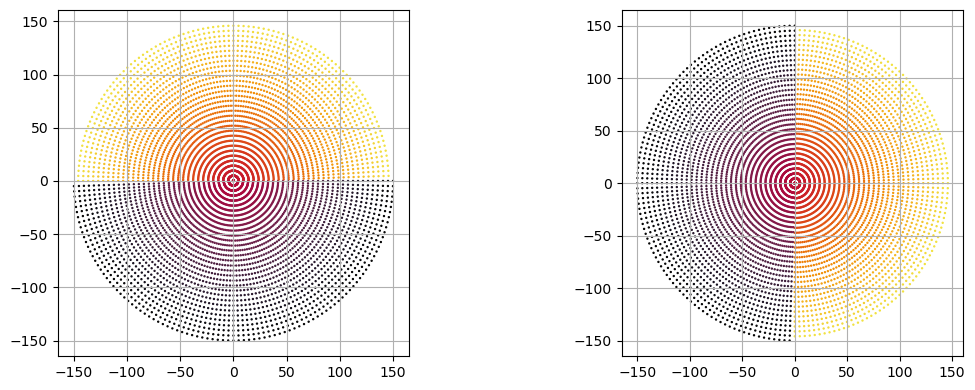

In [32]:
##NOTE: Definitely `sample=slice(0,-1,8)` but why diff colour? <<-- changed color to 'sample'
pre=rpre
rlp.plot.traj2d(f'{pre}.h5', sample=slice(0,-1,8), color='sample')

[15:53:25] [Traj  ] Discarded 3512 points (7.15%) outside matrix
[15:53:26] [Traj  ] Discarded 3512 points (7.15%) outside matrix


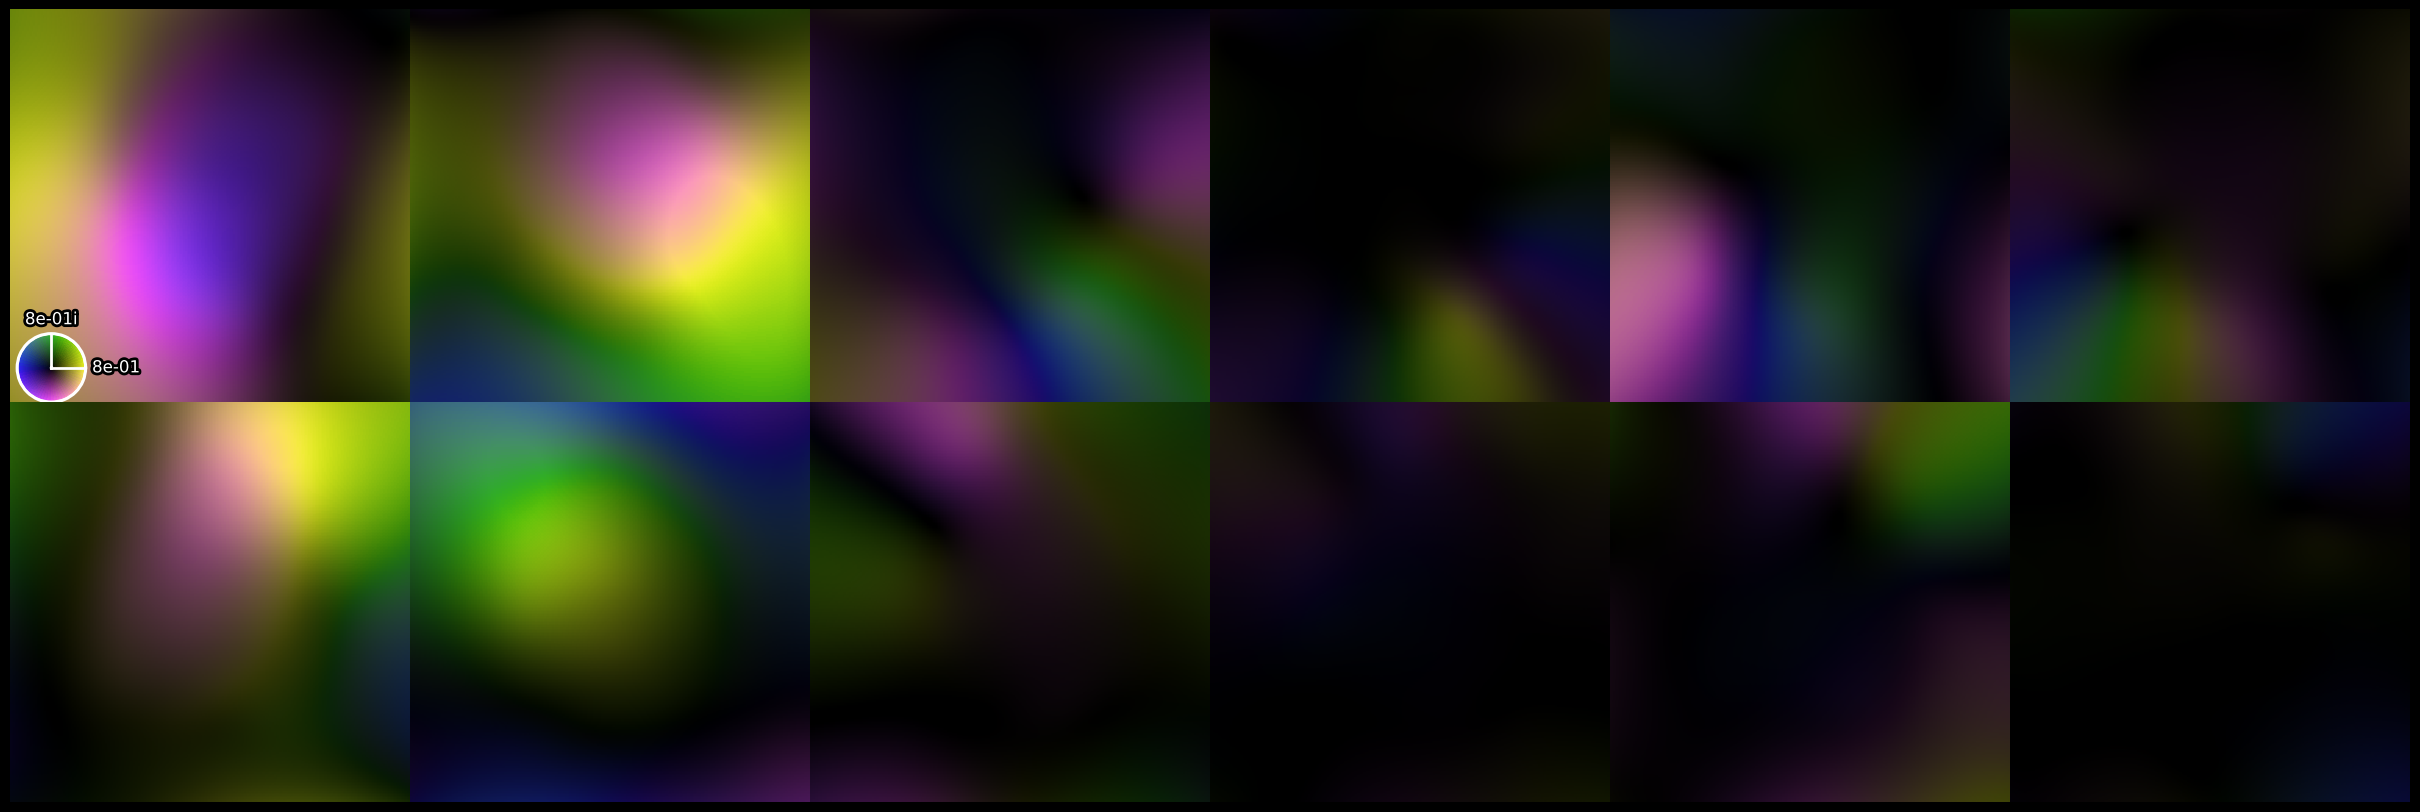

In [34]:
!riesling sense-calib2 {pre}.h5 {pre}-sk.h5
!riesling sense-maps2 {pre}-sk.h5 {pre}.h5 {pre}-sm.h5
display(rlp.plot.sense(f'{pre}-sm.h5',rows=2,rotates=1))

In [38]:
rlp.plot.noncart(f'{pre}.h5')

KeyError: 'channel'

In [29]:
#sigpy_sense = "/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE/riselingwork/rrsg/rrsg-radial-sigpy-sense.h5"

#rlp.plot.sense(sigpy_sense,rows=2,rotates=2)

[15:54:43] [Traj  ] Discarded 3512 points (7.15%) outside matrix
[15:54:44] [Traj  ] Discarded 3512 points (7.15%) outside matrix


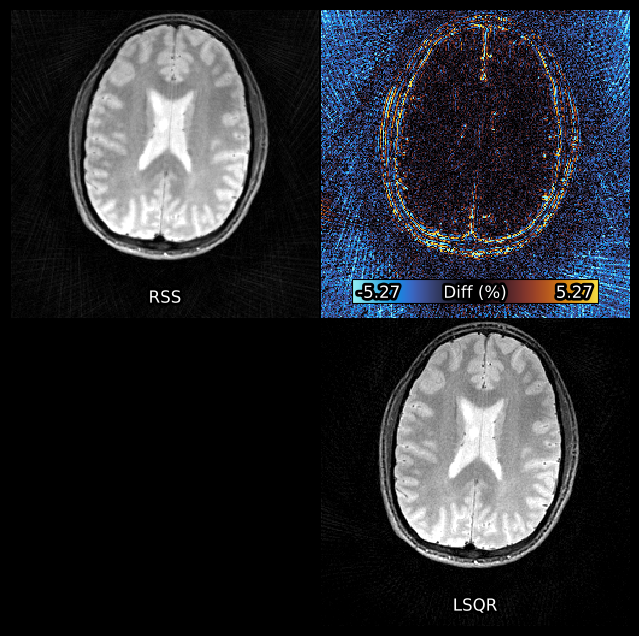

In [40]:
algos={'rss':'recon-rss2', 'lsqr':'recon-lsq2'}
recons=['rss', 'lsqr']
titles=['RSS', 'LSQR']
for t in recons:
    algo = algos[t]
    !riesling "{algo}" "{rpre}.h5" "{rpre}-{t}"
files=[f'{rpre}-{t}.h5' for t in recons]
rlp.plot.diff_matrix(files, titles=titles, rotates=1)

In [42]:
!riesling recon-lsq2 --precon-p=1 --sense="{rpre}-sk.h5" "{rpre}.h5" "{rpre}-lsq.h5" -v2

[15:55:06] [recon-lsq2] Welcome to RIESLING
[15:55:06] [HD5   ] Opened rrsg/rrsg-radial.h5 for reading id 72057594037927936
[15:55:06] [Traj  ] Discarded 3512 points (7.15%) outside matrix
[15:55:06] [Traj  ] 2D Samples 512 Traces 96 Matrix [256, 256] FOV [199.68, 199.68]
[15:55:06] [HD5   ] Opened rrsg/rrsg-radial-sk.h5 for reading id 72057594037927937
[15:55:06] [Traj  ] Nominal FOV, matrix [256, 256]
[15:55:06] [SENSE ] Normalizing to RSS
[15:55:06] [Kernel] Exponential Semi-Circle width 4 β 7.578488
[15:55:06] [Kernel] Width 4 Scale 1.5302638e-06
[15:55:06] [Traj  ] Nominal FOV, matrix [256, 256]
[15:55:06] [Traj  ] Nominal matrix [256, 256] grid matrix [332, 332] over-sampling [1.30, 1.30]
[15:55:06] [Traj  ] Ignored 3562 invalid trajectory points, 45590 remain
[15:55:06] [Traj  ] Nominal FOV, matrix [256, 256]
[15:55:06] [Kernel] Exponential Semi-Circle width 4 β 7.578488
[15:55:06] [Kernel] Width 4 Scale 1.5302638e-06
[15:55:06] [Apodiz] Shape [256, 256] Grid shape [332, 332] Sc

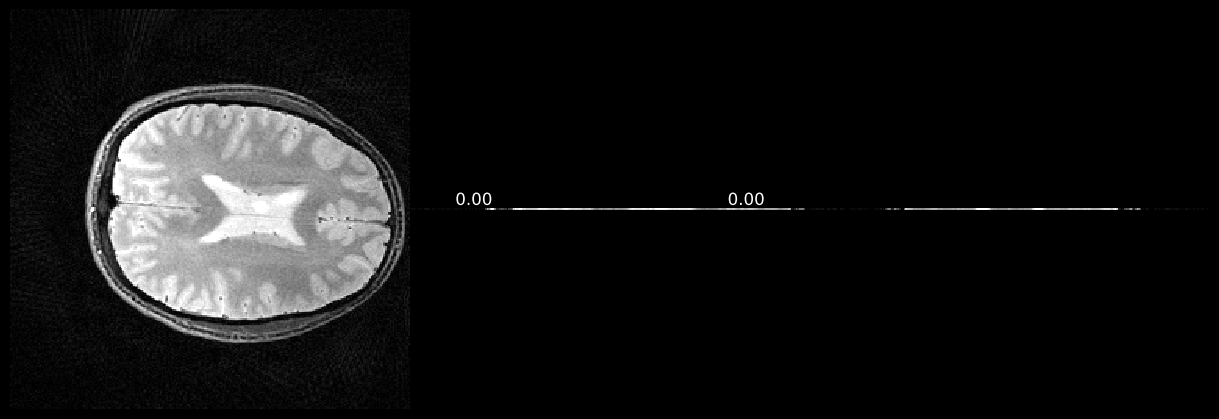

In [43]:
rlp.plot.planes(f"{rpre}-lsq.h5")

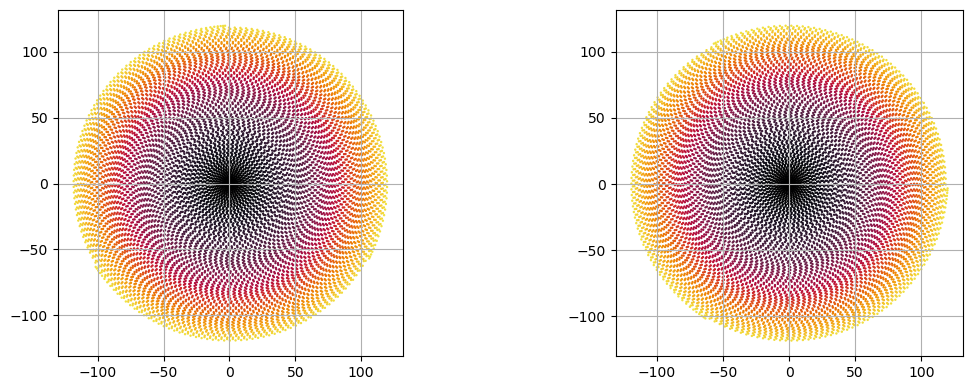

In [46]:
rlp.plot.traj2d(f'{spre}.h5', sample=slice(0,-1,8), color='sample')

[15:55:33] [Traj  ] Discarded 4132 points (5.08%) outside matrix
[15:55:33] [Traj  ] Discarded 4132 points (5.08%) outside matrix


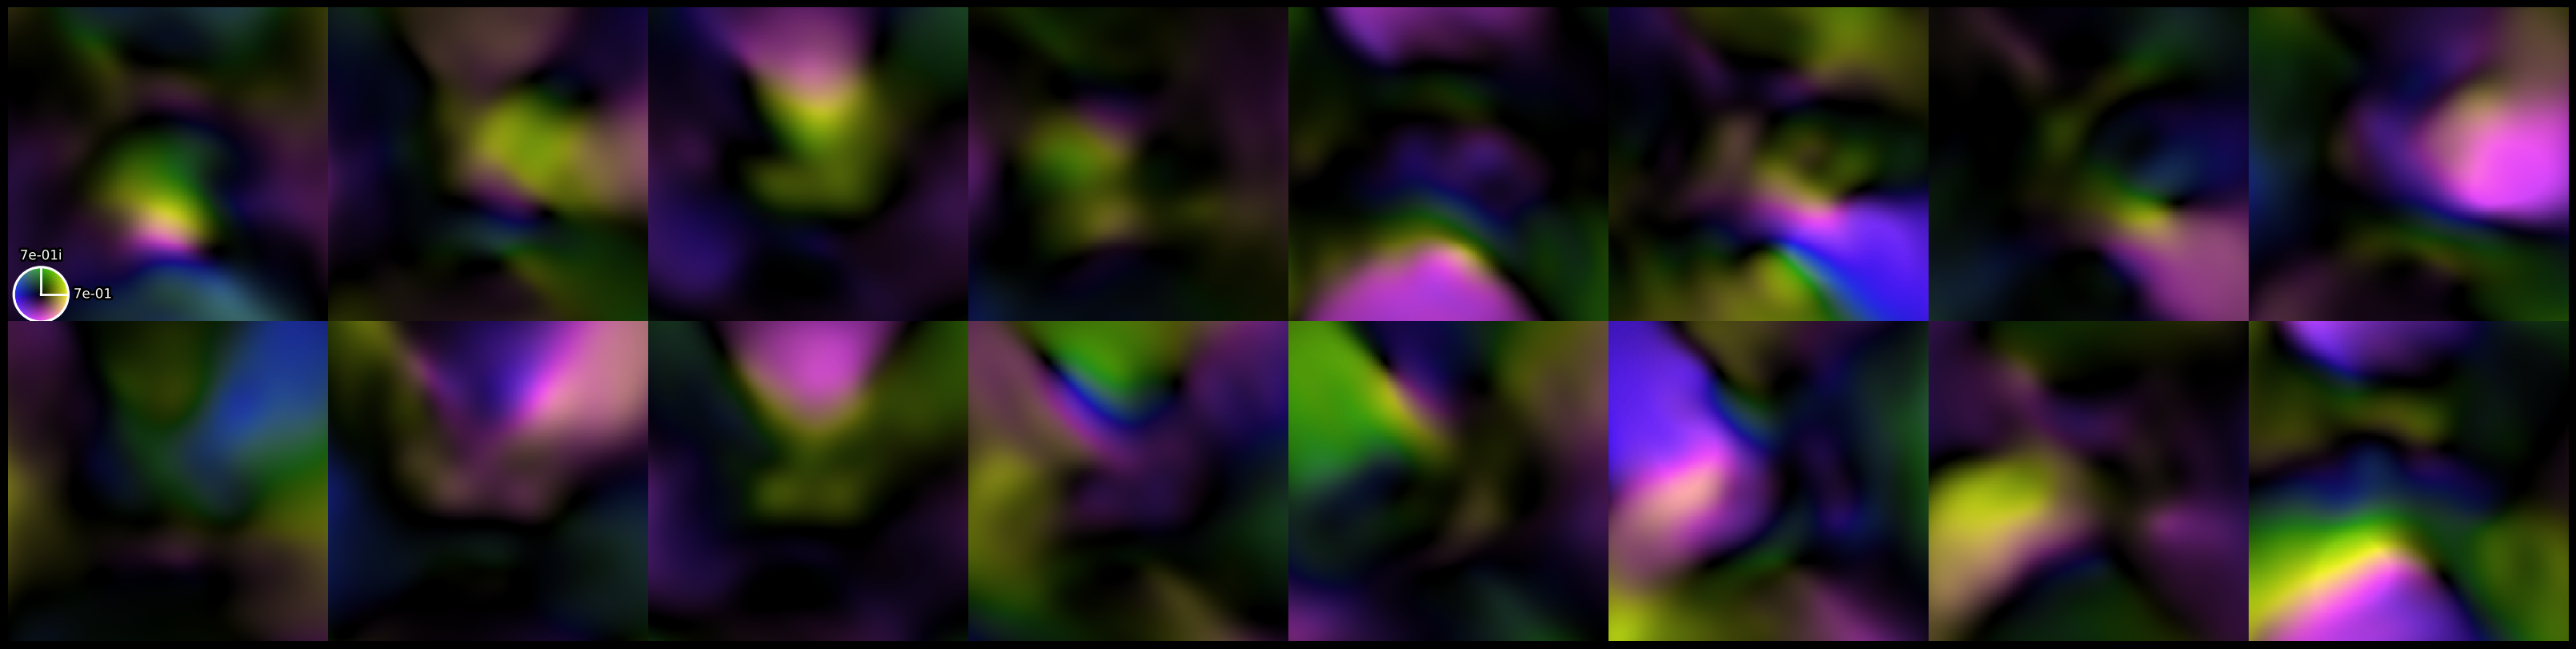

In [47]:
!riesling sense-calib2 "{spre}.h5" "{spre}-sk.h5"
!riesling sense-maps2 "{spre}-sk.h5" "{spre}.h5" "{spre}-sm.h5"
display(rlp.plot.sense(f'{spre}-sm.h5',rows=2,rotates=1))

[15:55:37] [Traj  ] Discarded 4132 points (5.08%) outside matrix
[15:55:38] [Traj  ] Discarded 4132 points (5.08%) outside matrix


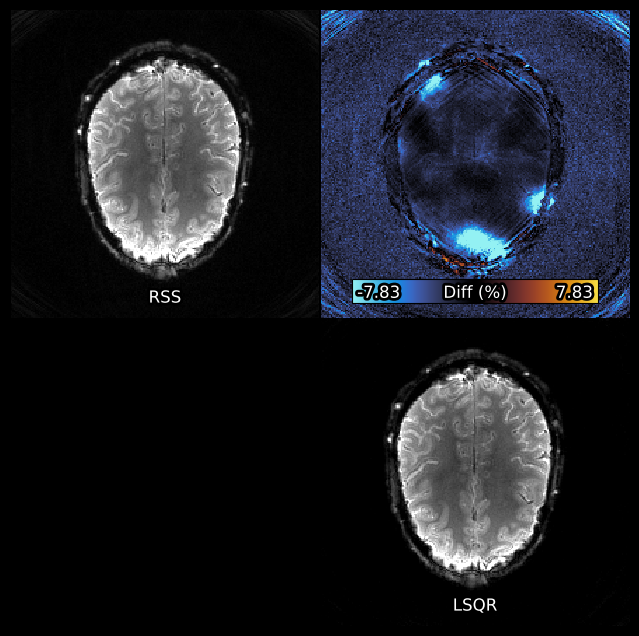

In [48]:
algos={'rss':'recon-rss2', 'lsqr':'recon-lsq2'}
recons=['rss', 'lsqr']
titles=['RSS', 'LSQR']
for t in recons:
    algo = algos[t]
    !riesling "{algo}" "{spre}.h5" "{spre}-{t}"
files=[f'{spre}-{t}.h5' for t in recons]
rlp.plot.diff_matrix(files, titles=titles, rotates=1)

- check fov `Could not read FOV from 'ov=256,256,2`
- check `sense-res` <<-- what did this change to>
- check `Error reading attribute matrix from trajectory.`